# Линейная регрессия: практика

In [18]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

random_seed = 42
np.random.seed(random_seed)

## Аналитическое решение

Сгенерируем матрицу признаков $X$ и коэффициенты регрессии $\mathbf{w}$. Вектор признаков посчитаем как $Y = X \times \mathbf{w} + \varepsilon$, где $\varepsilon \sim \mathcal{N}(0, 1)$

In [19]:
num_features = 2
num_objects = 3000

# Генерируем коэффициенты регрессии
w_true = np.random.normal(size=(num_features,))

# Генерируем матрицу признаков
X = np.random.uniform(-5, 5, (num_objects, num_features))

# Генерируем вектор таргетов, добавляя нормальный шум
Y = X @ w_true + np.random.normal(0, 1, num_objects)

Будем решать задачу поиска коэффициентов в случае линейной модели
$$\hat{Y} = X \times \mathbf{w}$$
и квадратичной функции ошибок
$$Q(Y, X, \mathbf{w}) = \sum_i (y_i - \mathbf{x_i}^T\mathbf{w})^2$$

Найдем аналитическое решение по формуле:
$$\mathbf{w}^* = (X^TX)^{-1}X^TY.$$

In [20]:
w_star = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(Y)

In [21]:
w_star

array([ 0.49062019, -0.1427943 ])

In [22]:
w_true

array([ 0.49671415, -0.1382643 ])

Можно заметить, что аналитическое решение довольно близко к оригиналу

Теперь сгенерируем датасет с скореллированными признаками

In [23]:
num_features = 3
num_objects = 3000
batch_size = 10
eps = 1e-3

# Генерируем коэффициенты регрессии
w_true = np.random.normal(size=(num_features,))

# Генерируем матрицу признаков
X = np.random.uniform(-5, 5, (num_objects, num_features))

# Продублируем предпоследний признак с небольшим шумом, сделав признаки 2 и 3 коллинеарными
X[:, -1] = X[:, -2] + np.random.uniform(-eps, eps, num_objects)

# Генерируем вектор таргетов, добавляя нормальный шум
Y = X @ w_true + np.random.normal(0, 1, num_objects)

In [24]:
w_star = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(Y)

In [25]:
w_star

array([  0.11532475,  33.97545722, -32.9329067 ])

In [26]:
w_true

array([ 0.11770742, -1.67176127,  2.71033164])

Видим что в данном случае коэффициенты у второго и третьего признаков противоположны, это делает нашу модель нестабильной

Исправим это **регуляризацией**

Добавил в функию ошибок слагаемое, отвечающее за $L_2$-норму весов

$$Q_{reg}(Y, X, \mathbf{w}) = \sum_i (y_i - \mathbf{x_i}^T\mathbf{w})^2 + \sum_p w_p^2$$

В таком случае аналитическое решение имеет вид
$$\mathbf{w_{reg}}^* = (X^TX + \lambda I_p)^{-1}X^TY,$$
где $I_p$ это матрица размером $p \times p$ с единицами на диагонали

In [27]:
w_star_reg = np.linalg.inv(X.T.dot(X) + 0.05*np.eye(num_features)).dot(X.T).dot(Y)
w_star_reg

array([0.1153149 , 0.85976566, 0.18282197])

In [28]:
w_true

array([ 0.11770742, -1.67176127,  2.71033164])

## Градиентный спуск

Суть градиентного спуска состоит в том, что мы итеративно меняем вектор весов, чтобы минимизировать функцию ошибки, двигаясь по антиградиенту
$$\mathbf{w}^{(t + 1)} = \mathbf{w}^{(t)} - \eta_t \nabla Q(\mathbf{w}^{(t)})$$

Для нашей квадратичной функции потерь градиент выглядит так:
$$\nabla Q(\mathbf{w}) = 2X^T(X\mathbf{w} - Y)$$

In [29]:
num_features = 2
num_objects = 3000
batch_size = 10
num_steps = 20

# Генерируем коэффициенты регрессии
w_true = np.random.normal(size=(num_features,))

# Генерируем матрицу признаков
X = np.random.uniform(-5, 5, (num_objects, num_features))

# Генерируем вектор таргетов, добавляя нормальный шум
Y = X @ w_true + np.random.normal(0, 1, num_objects)

In [30]:
w = np.random.uniform(-2, 2, num_features)
w_list = [w.copy()]
learning_rate = 1e-2

for i in range(num_steps):
    w -= learning_rate * 2 * X.T @ (X @ w - Y) / num_objects
    w_list.append(w.copy())

w_list = np.array(w_list)

In [31]:
w

array([-2.06318904, -0.38680978])

In [32]:
w_true

array([-2.07559506, -0.4449702 ])

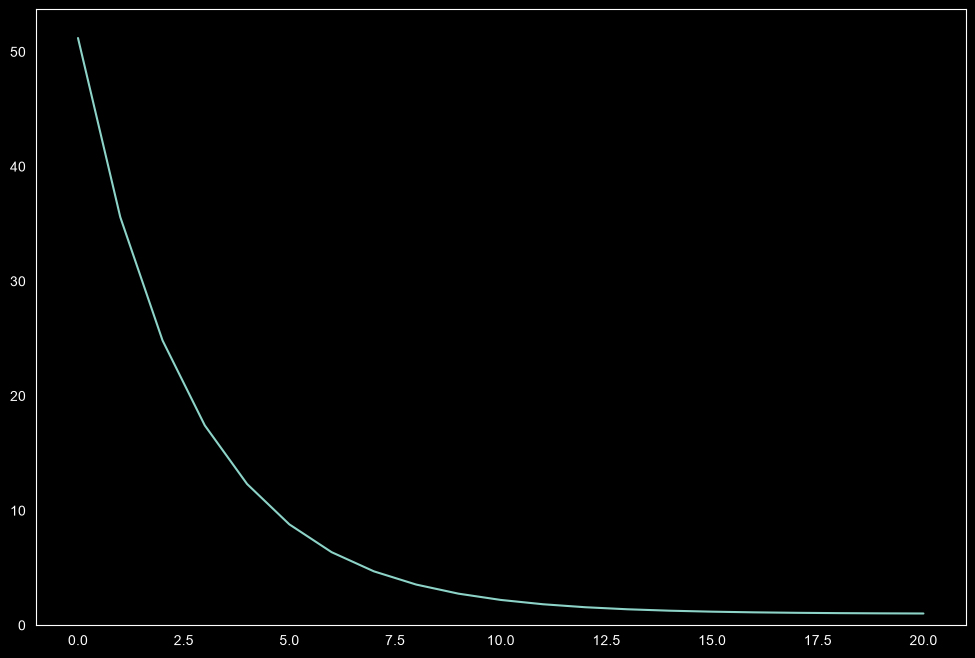

In [33]:
plt.figure(figsize=(12, 8))
plt.plot(np.square(X @ w_list.T - Y[:, None]).mean(axis=0))
plt.ylim(bottom=0)
plt.grid()
plt.show()

## Стохастический градиентный спуск

Отличие стохастического градиентного спуска заключается в том, что градиент считается по батчу. Приведем пример для размера батча 10

In [34]:
w = np.random.uniform(-2, 2, num_features)
w_list = [w.copy()]
learning_rate = 1e-2

for i in range(2 * batch_size):
    sample_indices = np.random.randint(0, num_objects, batch_size)
    X_batch = X[sample_indices, :]
    Y_batch = Y[sample_indices]
    w -= learning_rate * 2 * X_batch.T @ (X_batch @ w - Y_batch) / batch_size
    w_list.append(w.copy())

w_list = np.array(w_list)

In [35]:
w

array([-2.06802978, -0.46484807])

In [36]:
w_true

array([-2.07559506, -0.4449702 ])

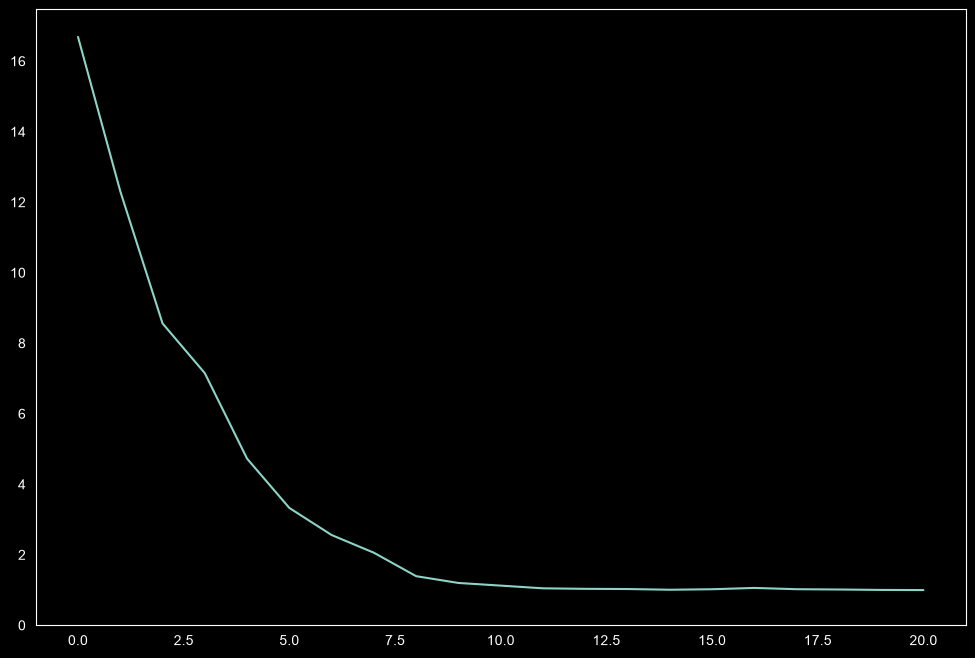

In [37]:
plt.figure(figsize=(12, 8))
plt.plot(np.square(X @ w_list.T - Y[:, None]).mean(axis=0))
plt.ylim(bottom=0)
plt.grid()
plt.show()

## Готовые решения из модуля sklearn

In [38]:
import seaborn as sns
from sklearn import linear_model, metrics, datasets

Рассмотрим датасет с развитием диабета у людей

In [39]:
X, Y = datasets.load_diabetes(as_frame=True, return_X_y=True)

In [40]:
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [41]:
Y

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

Используем модель из модуля `sklearn` - `LinearRegression`.

Также в этом модуле представлены варианты регрессии с регуляризацией:

1) `Lasso`

2) `Ridge`

3) `ElasticNet`

Эти классы имеют два основных метода:

1) `fit(X, Y)` обучает модель

2) `predict(X)` применяет модель

В качестве метрик будем использовать $MSE$ и $R^2$

Реализуем обучение модели и подсчет метрик без перебора гиперпараметров (`get_result`), а также с перебором гиперпараметра `alpha`, отвечающего за силу влияния регуляризации (`get_result_best_hyperparams`)

In [42]:
def get_result(model_class, X_train, X_test, Y_train, Y_test):
    model = model_class()
    model.fit(X_train, Y_train)
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)
    train_mse = metrics.mean_squared_error(Y_train, Y_train_pred)
    test_mse = metrics.mean_squared_error(Y_test, Y_test_pred)
    train_r2 = metrics.r2_score(Y_train, Y_train_pred)
    test_r2 = metrics.r2_score(Y_test, Y_test_pred)
    print(f"Train MSE: {train_mse:.3}")
    print(f"Test MSE: {test_mse:.3}")
    print(f"Train R2: {train_r2:.3}")
    print(f"Test R2: {test_r2:.3}")
    return model, Y_train_pred, Y_test_pred, train_mse, test_mse, train_r2, test_r2

In [43]:
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

def get_result_best_hyperparams(model_class, X_train, X_test, Y_train, Y_test):
    best_test_mse = np.inf
    best_alpha = None

    for alpha in alphas:
        model = model_class(alpha=alpha)
        model.fit(X_train, Y_train)
        test_mse = metrics.mean_squared_error(Y_test, model.predict(X_test))
        if test_mse < best_test_mse:
            best_test_mse = test_mse
            best_alpha = alpha

    model = model_class(alpha=best_alpha)
    model.fit(X_train, Y_train)
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)
    train_mse = metrics.mean_squared_error(Y_train, Y_train_pred)
    test_mse = metrics.mean_squared_error(Y_test, Y_test_pred)
    train_r2 = metrics.r2_score(Y_train, Y_train_pred)
    test_r2 = metrics.r2_score(Y_test, Y_test_pred)
    print(f"Train MSE: {train_mse:.3}")
    print(f"Test MSE: {test_mse:.3}")
    print(f"Train R2: {train_r2:.3}")
    print(f"Test R2: {test_r2:.3}")
    return model, Y_train_pred, Y_test_pred, train_mse, test_mse, train_r2, test_r2

Разобьем датасет случайным образом на обучающую (_train) и тестовую (_test) части

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.9)

Проверим, есть ли коллинеарные признаки. Для этого построим корреляционную матрицу признаков, и проверим есть ли единицы вне главной диагонали

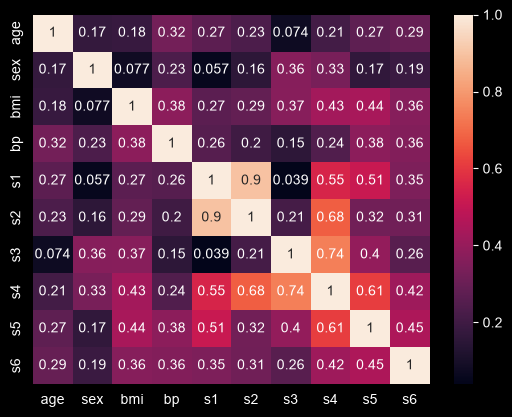

In [63]:
sns.heatmap(np.abs(X_train.corr()), annot=True)
plt.show()

В данном случае критичных корреляций нет

Лучшей практикой является нормирование признаков, что повышает стабильность и упрощает интерпретируемость

In [64]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
X_scaler.fit(X_train)
X_train = pd.DataFrame(X_scaler.transform(X_train), columns=X_scaler.get_feature_names_out())
X_test = pd.DataFrame(X_scaler.transform(X_test), columns=X_scaler.get_feature_names_out())

Будем сохранять метрики на тестовой выборке по нашим моделям для дальнейшего сравнения

In [65]:
metrics_values = {
    "test_mse": [],
    "test_r2": []
}
model_name = []

Линейная регрессия

In [66]:
model, Y_train_pred, Y_test_pred, train_mse, test_mse, train_r2, test_r2 = get_result(linear_model.LinearRegression, X_train, X_test, Y_train, Y_test)
metrics_values["test_mse"].append(test_mse)
metrics_values["test_r2"].append(test_r2)
model_name.append("LinearRegression")

Train MSE: 2.81e+03
Test MSE: 3.39e+03
Train R2: 0.506
Test R2: 0.566


Для того чтобы понять, какой вклад дают разные переменные, рассмотрим коэффициенты у соответствующих признаков

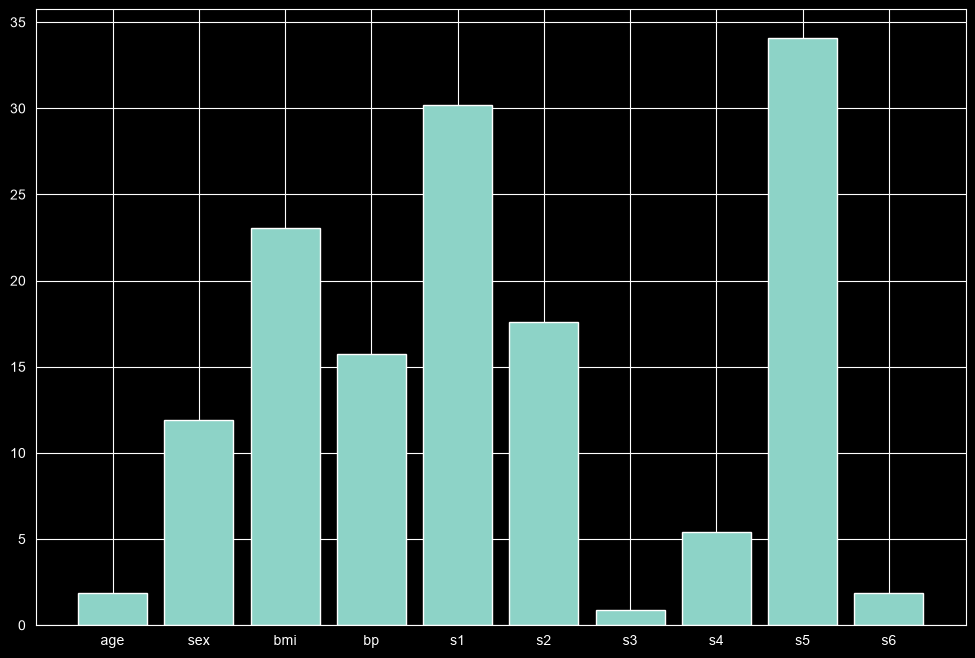

In [67]:
plt.figure(figsize=(12, 8))
plt.bar(X_train.columns, np.abs(model.coef_))
plt.show()

Ridge регрессия с перебором гиперпараметров

In [68]:
model, Y_train_pred, Y_test_pred, train_mse, test_mse, train_r2, test_r2 = get_result_best_hyperparams(linear_model.Ridge, X_train, X_test, Y_train, Y_test)
metrics_values["test_mse"].append(test_mse)
metrics_values["test_r2"].append(test_r2)
model_name.append("Ridge")

Train MSE: 2.81e+03
Test MSE: 3.39e+03
Train R2: 0.506
Test R2: 0.566


Lasso регрессия с перебором гиперпараметров

In [51]:
model, Y_train_pred, Y_test_pred, train_mse, test_mse, train_r2, test_r2 = get_result_best_hyperparams(linear_model.Lasso, X_train, X_test, Y_train, Y_test)
metrics_values["test_mse"].append(test_mse)
metrics_values["test_r2"].append(test_r2)
model_name.append("Lasso")

Train MSE: 2.87e+03
Test MSE: 3.01e+03
Train R2: 0.517
Test R2: 0.452


ElasticNet с перебором гиперпараметров

In [52]:
model, Y_train_pred, Y_test_pred, train_mse, test_mse, train_r2, test_r2 = get_result_best_hyperparams(linear_model.ElasticNet, X_train, X_test, Y_train, Y_test)
metrics_values["test_mse"].append(test_mse)
metrics_values["test_r2"].append(test_r2)
model_name.append("ElasticNet")

Train MSE: 2.93e+03
Test MSE: 2.98e+03
Train R2: 0.507
Test R2: 0.457


Сравним метрики по моделям

In [53]:
pd.DataFrame(metrics_values, index=model_name)

,test_mse,test_r2
LinearRegression,3106.916422,0.434862
Ridge,3031.695498,0.448545
Lasso,3013.697640,0.451819
ElasticNet,2984.186660,0.457186


Добавим квадраты и попарные произведения исходных признаков, чтобы улучшить качество модели

In [54]:
num_features = X.shape[1]
for i in range(num_features):
    column = X.columns[i]
    X_train[f"{column}_squared"] = X_train[column] ** 2
    X_test[f"{column}_squared"] = X_test[column] ** 2

    for j in range(i + 1, num_features):
        other_column = X.columns[j]
        X_train[f"{column}_x_{other_column}"] = X_train[column] * X_train[other_column]
        X_test[f"{column}_x_{other_column}"] = X_test[column] * X_test[other_column]

In [55]:
X_train

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,...,s3_squared,s3_x_s4,s3_x_s5,s3_x_s6,s4_squared,s4_x_s5,s4_x_s6,s5_squared,s5_x_s6,s6_squared
0,2.347560,1.054373,-0.687074,-0.487269,-0.095599,0.425592,-1.308214,1.542255,0.354572,0.933751,...,1.711423,-2.017599,-0.463856,-1.221546,2.378551,0.546841,1.440082,0.125722,0.331082,0.871891
1,-1.662952,1.054373,1.656337,1.087613,1.673754,1.365499,0.524690,-0.038075,0.899046,-0.210926,...,0.275299,-0.019978,0.471720,-0.110671,0.001450,-0.034231,0.008031,0.808284,-0.189632,0.044490
2,-0.197573,-0.948431,-0.323049,1.445541,0.258272,0.465588,0.295577,-0.038075,-0.704127,1.021803,...,0.087366,-0.011254,-0.208123,0.302021,0.001450,0.026810,-0.038905,0.495794,-0.719479,1.044081
3,0.265179,-0.948431,0.496007,1.087613,0.169804,-0.614305,0.753803,-0.828240,1.203706,-0.563134,...,0.568218,-0.624330,0.907357,-0.424492,0.685982,-0.996958,0.466410,1.448909,-0.677848,0.317120
4,-0.660324,1.054373,0.609765,1.445541,-2.720138,-2.280807,-1.155472,-1.009978,-0.649956,0.317387,...,1.335115,1.167001,0.751006,-0.366731,1.020056,0.656441,-0.320554,0.422443,-0.206287,0.100734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,0.650805,1.054373,1.269561,1.159199,-0.478958,0.018965,-0.697246,-0.038075,-0.520856,-0.387030,...,0.486152,0.026548,0.363165,0.269855,0.001450,0.019832,0.014736,0.271291,0.201587,0.149792
393,-1.817203,1.054373,-0.641571,-0.487269,-1.363634,-1.160918,0.371948,-0.828240,-2.074603,-0.739238,...,0.138345,-0.308062,-0.771644,-0.274958,0.685982,1.718270,0.612267,4.303978,1.533625,0.546473
394,-0.120447,-0.948431,0.928287,1.803469,0.287761,0.145620,-0.315391,-0.038075,0.935226,-0.387030,...,0.099471,0.012009,-0.294962,0.122066,0.001450,-0.035609,0.014736,0.874647,-0.361960,0.149792
395,-0.274698,-0.948431,-1.369622,-1.465843,0.022358,0.352266,-0.086278,-0.132895,-0.649956,-1.091446,...,0.007444,0.011466,0.056077,0.094168,0.017661,0.086376,0.145048,0.422443,0.709392,1.191255


In [56]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
X_scaler.fit(X_train)
X_train = pd.DataFrame(X_scaler.transform(X_train), columns=X_scaler.get_feature_names_out())
X_test = pd.DataFrame(X_scaler.transform(X_test), columns=X_scaler.get_feature_names_out())

In [57]:
X_train

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,...,s3_squared,s3_x_s4,s3_x_s5,s3_x_s6,s4_squared,s4_x_s5,s4_x_s6,s5_squared,s5_x_s6,s6_squared
0,2.347560,1.054373,-0.687074,-0.487269,-0.095599,0.425592,-1.308214,1.542255,0.354572,0.933751,...,0.414058,-1.158977,-0.087126,-1.020148,0.934257,-0.050604,0.975091,-0.643892,-0.114152,-0.082990
1,-1.662952,1.054373,1.656337,1.087613,1.673754,1.365499,0.524690,-0.038075,0.899046,-0.210926,...,-0.421786,0.664270,0.964508,0.159050,-0.676727,-0.642274,-0.358753,-0.141196,-0.603751,-0.618985
2,-0.197573,-0.948431,-0.323049,1.445541,0.258272,0.465588,0.295577,-0.038075,-0.704127,1.021803,...,-0.531166,0.672232,0.200330,0.597123,-0.676727,-0.580120,-0.402471,-0.371340,-1.101937,0.028556
3,0.265179,-0.948431,0.496007,1.087613,0.169804,-0.614305,0.753803,-0.828240,1.203706,-0.563134,...,-0.251303,0.112672,1.454185,-0.174073,-0.212813,-1.622560,0.068192,0.330614,-1.062794,-0.442374
4,-0.660324,1.054373,0.609765,1.445541,-2.720138,-2.280807,-1.155472,-1.009978,-0.649956,0.317387,...,0.195041,1.747636,1.278439,-0.112760,0.013592,0.060996,-0.664804,-0.425362,-0.619411,-0.582550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,0.650805,1.054373,1.269561,1.159199,-0.478958,0.018965,-0.697246,-0.038075,-0.520856,-0.387030,...,-0.299067,0.706734,0.842486,0.562978,-0.676727,-0.587225,-0.352508,-0.536683,-0.235910,-0.550770
393,-1.817203,1.054373,-0.641571,-0.487269,-1.363634,-1.160918,0.371948,-0.828240,-2.074603,-0.739238,...,-0.501495,0.401333,-0.433095,-0.015342,-0.212813,1.142191,0.204046,2.433328,1.016533,-0.293798
394,-0.120447,-0.948431,0.928287,1.803469,0.287761,0.145620,-0.315391,-0.038075,0.935226,-0.387030,...,-0.524120,0.693464,0.102720,0.406100,-0.676727,-0.643677,-0.352508,-0.092320,-0.765782,-0.550770
395,-0.274698,-0.948431,-1.369622,-1.465843,0.022358,0.352266,-0.086278,-0.132895,-0.649956,-1.091446,...,-0.577681,0.692969,0.497305,0.376486,-0.665741,-0.519467,-0.231133,-0.425362,0.241551,0.123896


In [69]:
model, Y_train_pred, Y_test_pred, _, _, _, _ = get_result_best_hyperparams(linear_model.Lasso, X_train, X_test, Y_train, Y_test)

Train MSE: 2.81e+03
Test MSE: 3.39e+03
Train R2: 0.506
Test R2: 0.566


Проверим, является ли распределение ошибок нормальным, используя QQplot. Чем ближе точки к диагонали, тем больше распределение похоже на нормальное

In [70]:
from statsmodels.graphics.gofplots import qqplot

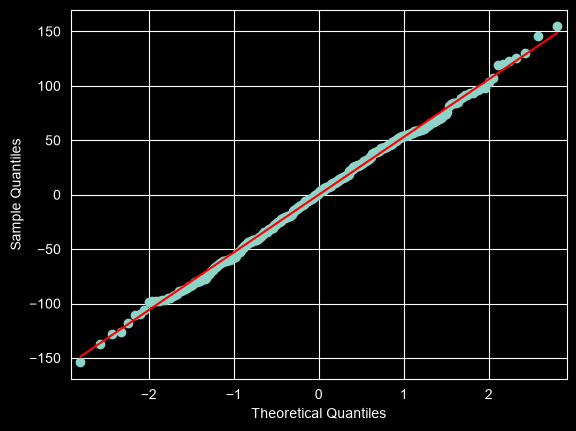

In [71]:
qqplot(Y_train_pred - Y_train, line='s')
plt.show()

Посмотрим на топ-3 наиболее важных признака

In [72]:
ind = np.argpartition(np.abs(model.coef_), -3)[-3:]
print(X_train.columns[ind].tolist())

['bmi', 's5', 's1']
